# Scalar Behavioral Metrics: Velocity & Distance

Computes and plots **mean velocity** and **total distance traveled** per animal at baseline, 7DPI, and 30DPI for each treatment (CS, WMS) × sex combination. Outliers are removed via IQR filtering within groups, and pairwise Mann-Whitney U tests are annotated directly on the bar plots.

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
try:
    from statannotations.Annotator import Annotator
except:
    !pip install statannotations
    from statannotations.Annotator import Annotator
import matplotlib.pyplot as plt

/home/llorente/[/home/llorente/miniconda3new]/envs/moseq2-new/lib/python3.7/site-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


## Setup & Data Loading

Loads MoSeq frame-level data and the stats summary. Filters out initialization frames (label < 0) and creates a composite `age_sex` label.

In [2]:
MODEL_PATH = Path('/mnt/g/Shared drives/llorente-lab/Moseq/AnalyzedData/Nature_Comms_Manuscript/')
MOSEQ_DF_PATH = MODEL_PATH / 'moseq_df.csv'
STATS_DF_PATH = MODEL_PATH / 'stats_df.csv'

moseq_df = pd.read_csv(MOSEQ_DF_PATH)
stats_df = pd.read_csv(STATS_DF_PATH)

print(moseq_df.shape)
print(stats_df.shape)

/home/llorente/[/home/llorente/miniconda3new]/envs/moseq2-new/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3063: DtypeWarning: Columns (31,32) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


(20241328, 37)
(26976, 95)


In [7]:
save_path = '/mnt/g/Shared drives/llorente-lab/Moseq/Manuscript/revision_resubmission/figures_revision_plots/Figures_supplementary'
os.makedirs(save_path, exist_ok=True)
SAVE_PATH = Path(save_path)

In [6]:
moseq_df = moseq_df[moseq_df['labels (usage sort)'] >= 0]
moseq_df.shape # make sure it's all okay

(20239642, 37)

In [9]:
moseq_df['age_sex'] = moseq_df['age'] + ' ' + moseq_df['sex']

## Metric Computation

Calculates frame-to-frame centroid displacement (Euclidean distance in pixels) and aggregates per animal per timepoint to get `total_distance` and `mean_velocity`.

In [55]:
from scipy.stats import mannwhitneyu
from statannotations.Annotator import Annotator
import itertools

# Step 1: compute total distance traveled per animal per timepoint
moseq_df['dist_traveled'] = np.sqrt(
    moseq_df['centroid_x_mm'].diff()**2 + moseq_df['centroid_y_mm'].diff()**2
)
# zero out transitions between sessions (where uuid changes)
moseq_df.loc[moseq_df['uuid'] != moseq_df['uuid'].shift(), 'dist_traveled'] = 0

distance_df = (
    moseq_df[moseq_df['labels (usage sort)'] >= 0]
    .groupby(['uuid', 'treatment', 'timepoint', 'age_sex'])
    .agg(
        total_distance=('dist_traveled', 'sum'),
        mean_velocity=('velocity_3d_mm', 'mean')
    )
    .reset_index()
)

## Color Scheme

Defines treatment × age group color palettes (`palette_4` for males, `palette_females` for females) and a `color_map` dictionary keyed on `(treatment, age_sex)` tuples.

In [11]:
# Step 2: define palettes
palette_4 = {
    'CS_YM': '#E69F00',
    'CS_AM': '#D55E00',
    'WMS_YM': '#56B4E9',
    'WMS_AM': '#0072B2',
}

palette_females = {
    'CS_YF': '#FFCC80',   # light orange
    'CS_AF': '#E65100',   # deep orange
    'WMS_YF': '#90CAF9',  # light blue
    'WMS_AF': '#1565C0',  # deep blue
}

# combined palette keyed by (treatment, age_sex)
color_map = {
    ('CS',  'young Male'):   palette_4['CS_YM'],
    ('CS',  'aged Male'):    palette_4['CS_AM'],
    ('WMS', 'young Male'):   palette_4['WMS_YM'],
    ('WMS', 'aged Male'):    palette_4['WMS_AM'],
    ('CS',  'young Female'): palette_females['CS_YF'],
    ('CS',  'aged Female'):  palette_females['CS_AF'],
    ('WMS', 'young Female'): palette_females['WMS_YF'],
    ('WMS', 'aged Female'):  palette_females['WMS_AF'],
}

## Helper Functions

`remove_outliers_iqr()` removes values outside 1.5 × IQR within each group. `plot_metric()` generates a barplot + stripplot with Mann-Whitney U annotations across timepoint pairs and saves as PDF.

In [18]:
def remove_outliers_iqr(df, metric, groupby_cols):
    clean_rows = []
    for keys, group in df.groupby(groupby_cols):
        q1 = group[metric].quantile(0.25)
        q3 = group[metric].quantile(0.75)
        iqr = q3 - q1
        filtered = group[(group[metric] >= q1 - 1.5 * iqr) & (group[metric] <= q3 + 1.5 * iqr)]
        clean_rows.append(filtered)
    return pd.concat(clean_rows).reset_index(drop=True)

In [81]:
from matplotlib.patches import Patch

def plot_metric(distance_df, stroke, sex, metric, ylabel, filename):
    timepoint_order = ['BSL', '7DPI', '30DPI']
    
    aged_label = f'aged {sex}'
    young_label = f'young {sex}'
    
    group_df = distance_df[
        (distance_df['treatment'] == stroke) &
        (distance_df['age_sex'].isin([aged_label, young_label])) &
        (distance_df['timepoint'].isin(timepoint_order))
    ]
    
    # remove outliers within each stroke x tp x age_sex combo
    group_df = remove_outliers_iqr(group_df, metric, groupby_cols=['treatment', 'timepoint', 'age_sex'])

    palette = {
        aged_label:  color_map[(stroke, aged_label)],
        young_label: color_map[(stroke, young_label)],
    }

    fig, ax = plt.subplots(figsize=(5, 5))
    fig.dpi = 300

    sns.barplot(
        data=group_df,
        x='timepoint', y=metric,
        hue='age_sex',
        order=timepoint_order,
        hue_order=[young_label, aged_label],
        palette=palette,
        ax=ax
    )

    sns.stripplot(
        data=group_df,
        x='timepoint', y=metric,
        hue='age_sex',
        order=timepoint_order,
        hue_order=[young_label, aged_label],
        palette={aged_label: 'black', young_label: 'black'},
        dodge=True,
        size=8, alpha=0.4, jitter=True,
        ax=ax
    )
    
    ax.get_legend().remove()

    # stats within each age_sex group across timepoints
    pairs = []
    for age_sex in [aged_label, young_label]:
        for tp1, tp2 in itertools.combinations(timepoint_order, 2):
            pairs.append(((tp1, age_sex), (tp2, age_sex)))

    annotator = Annotator(
        ax, pairs=pairs,
        data=group_df, x='timepoint', y=metric, hue='age_sex',
        order=timepoint_order, hue_order=[young_label, aged_label]
    )
    annotator.configure(test='Mann-Whitney', text_format='star', loc='outside')
    annotator.apply_and_annotate()

    #ax.set_title(f'{stroke} | {sex}', fontsize=12, fontweight='normal')
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    
    if metric == 'mean_velocity':
        ax.set_ylim(0, 7)
    else:
        ax.set_ylim(0, 250000)
    
    legend_handles = [
        Patch(facecolor=color_map[(stroke, young_label)], label=young_label),
        Patch(facecolor=color_map[(stroke, aged_label)], label=aged_label),
    ]
    ax.legend(handles=legend_handles, frameon=False, title=None)
    

    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(SAVE_PATH / filename, dpi=300, bbox_inches='tight')
    plt.show()

## Plot Generation

Iterates over all stroke × sex combinations (CS/WMS × Male/Female) and calls `plot_metric()` for both velocity and distance, producing 8 output PDFs.

In [70]:
distance_df['total_distance'].nlargest(5)

41     451763.877636
511    447500.961373
389    376116.546542
184    364934.688057
233    357869.384823
Name: total_distance, dtype: float64

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BSL_aged Male vs. 7DPI_aged Male: Mann-Whitney-Wilcoxon test two-sided, P_val:6.007e-05 U_stat=1.960e+02
7DPI_aged Male vs. 30DPI_aged Male: Mann-Whitney-Wilcoxon test two-sided, P_val:3.550e-02 U_stat=4.300e+01
BSL_young Male vs. 7DPI_young Male: Mann-Whitney-Wilcoxon test two-sided, P_val:1.302e-05 U_stat=4.220e+02
7DPI_young Male vs. 30DPI_young Male: Mann-Whitney-Wilcoxon test two-sided, P_val:4.067e-02 U_stat=3.000e+02
BSL_aged Male vs. 30DPI_aged Male: Mann-Whitney-Wilcoxon test two-sided, P_val:5.765e-04 U_stat=1.830e+02
BSL_young Male vs. 30DPI_young Male: Mann-Whitney-Wilcoxon test two-sided, P_val:5.085e-08 U_stat=5.520e+02


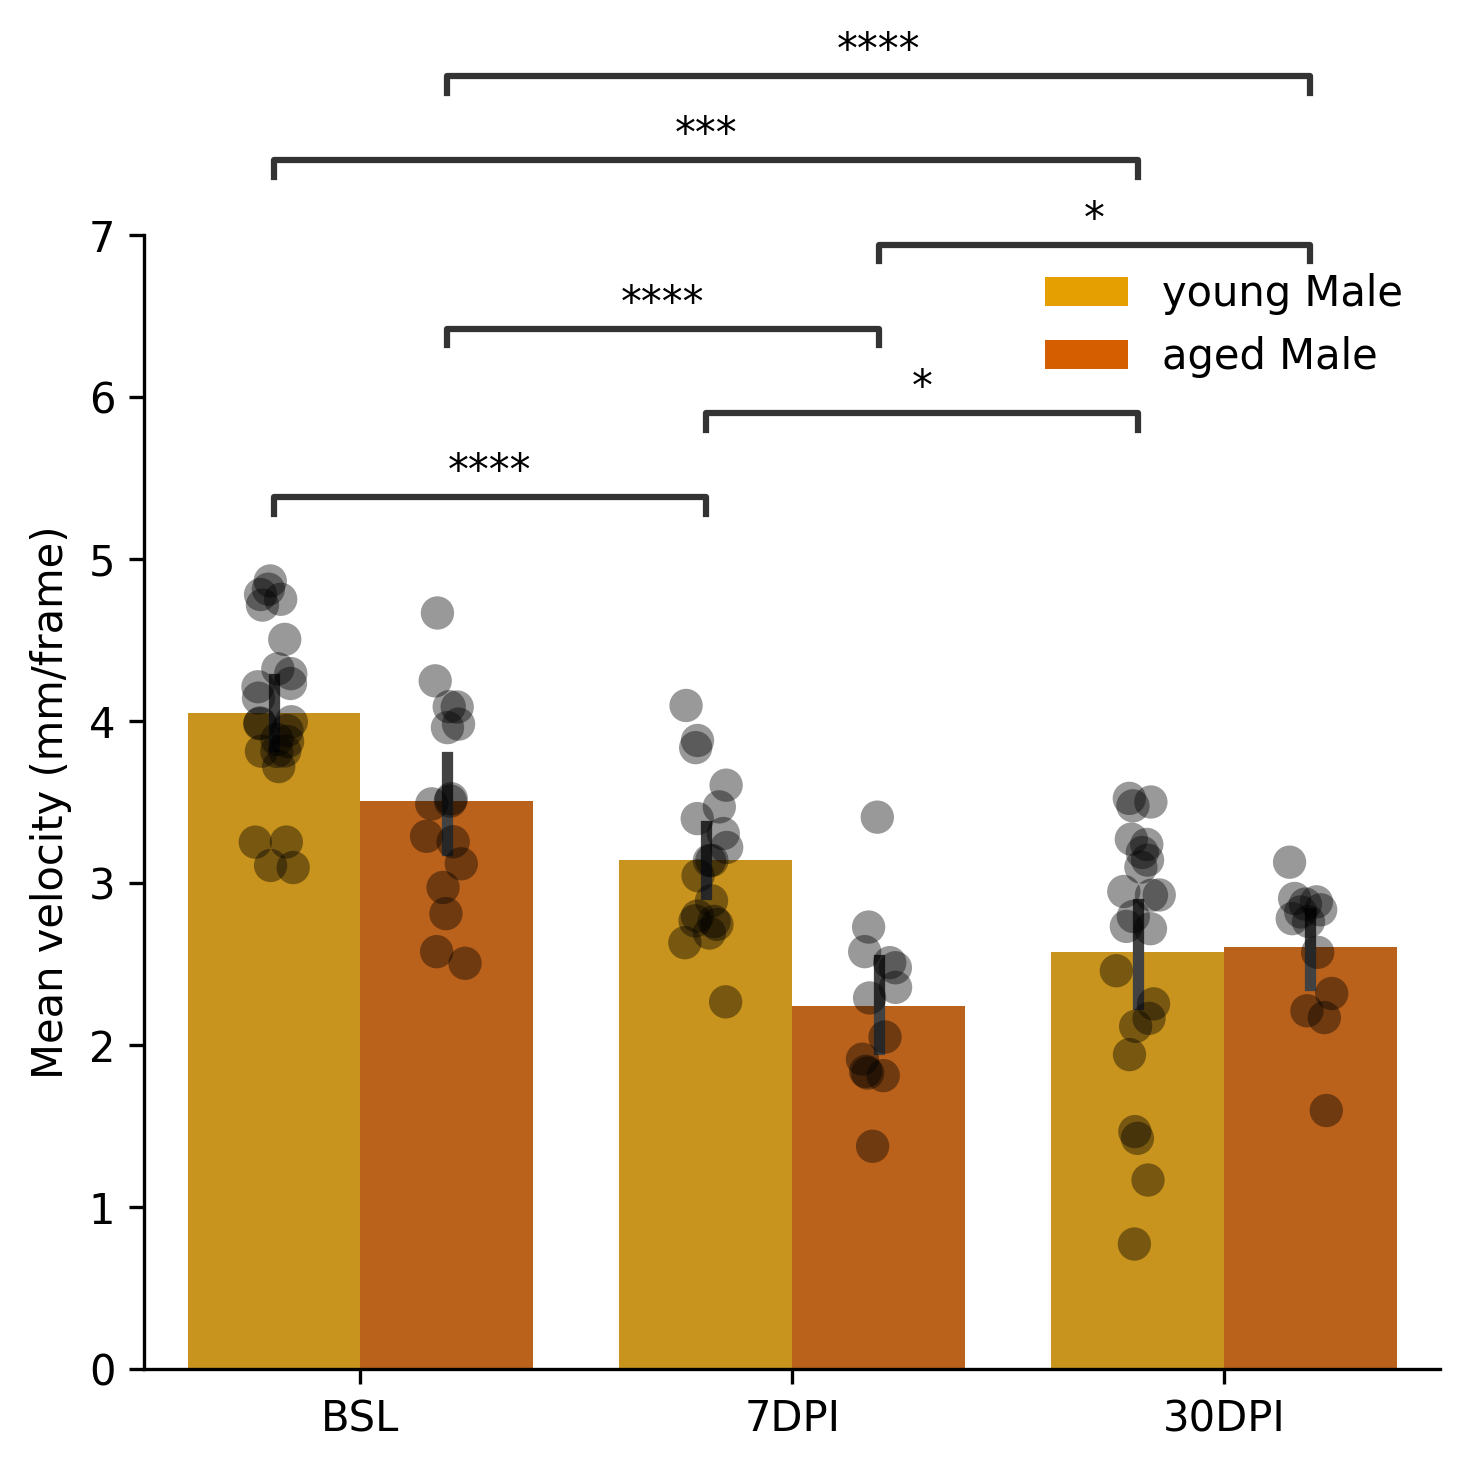

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BSL_aged Male vs. 7DPI_aged Male: Mann-Whitney-Wilcoxon test two-sided, P_val:4.127e-05 U_stat=1.980e+02
7DPI_aged Male vs. 30DPI_aged Male: Mann-Whitney-Wilcoxon test two-sided, P_val:1.264e-01 U_stat=5.900e+01
BSL_young Male vs. 7DPI_young Male: Mann-Whitney-Wilcoxon test two-sided, P_val:1.451e-05 U_stat=4.210e+02
7DPI_young Male vs. 30DPI_young Male: Mann-Whitney-Wilcoxon test two-sided, P_val:3.825e-02 U_stat=3.010e+02
BSL_aged Male vs. 30DPI_aged Male: Mann-Whitney-Wilcoxon test two-sided, P_val:1.988e-04 U_stat=2.020e+02
BSL_young Male vs. 30DPI_young Male: Mann-Whitney-Wilcoxon test two-sided, P_val:5.709e-08 U_stat=5.510e+02


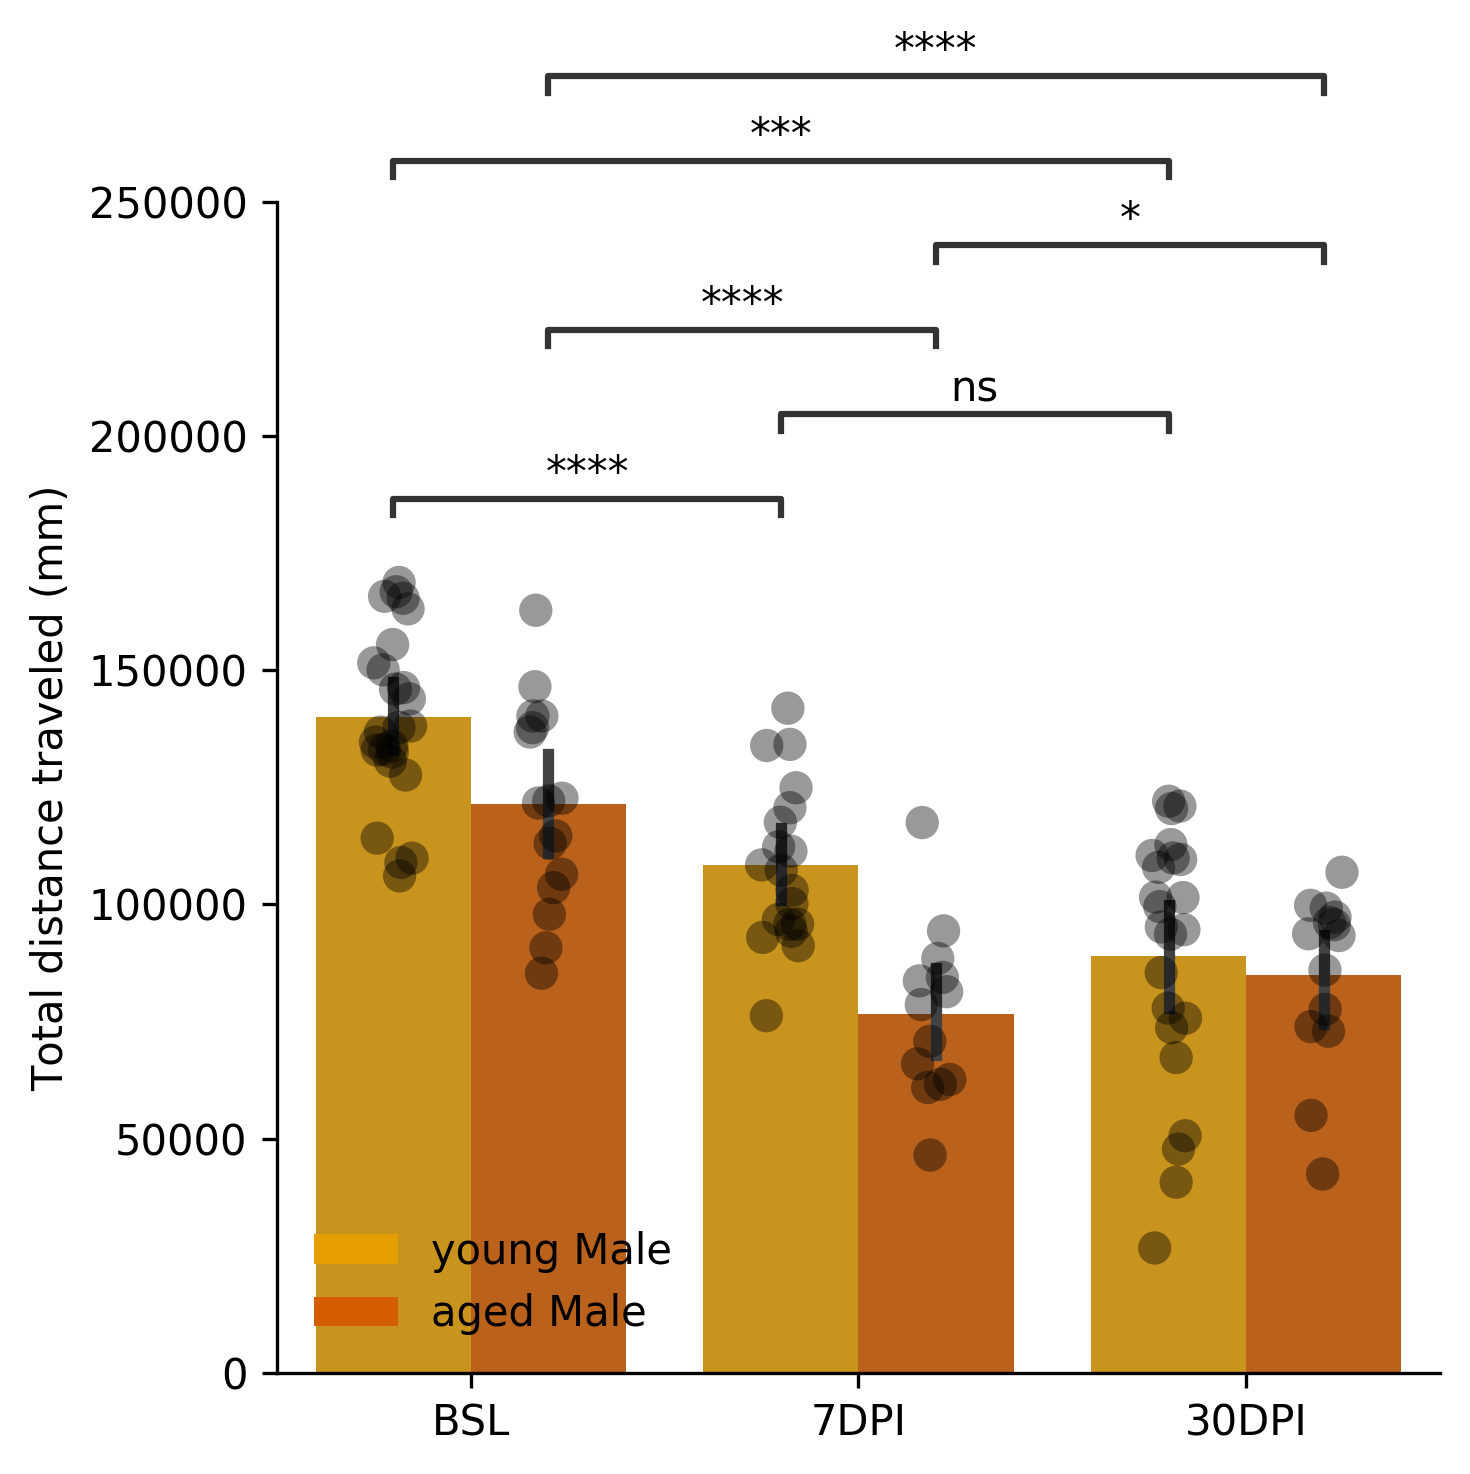

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BSL_aged Female vs. 7DPI_aged Female: Mann-Whitney-Wilcoxon test two-sided, P_val:2.091e-02 U_stat=8.700e+01
7DPI_aged Female vs. 30DPI_aged Female: Mann-Whitney-Wilcoxon test two-sided, P_val:4.379e-01 U_stat=5.500e+01
BSL_young Female vs. 7DPI_young Female: Mann-Whitney-Wilcoxon test two-sided, P_val:6.512e-02 U_stat=1.020e+02
7DPI_young Female vs. 30DPI_young Female: Mann-Whitney-Wilcoxon test two-sided, P_val:9.131e-01 U_stat=1.080e+02
BSL_aged Female vs. 30DPI_aged Female: Mann-Whitney-Wilcoxon test two-sided, P_val:7.574e-03 U_stat=1.010e+02
BSL_young Female vs. 30DPI_young Female: Mann-Whitney-Wilcoxon test two-sided, P_val:8.058e-02 U_stat=1.070e+02


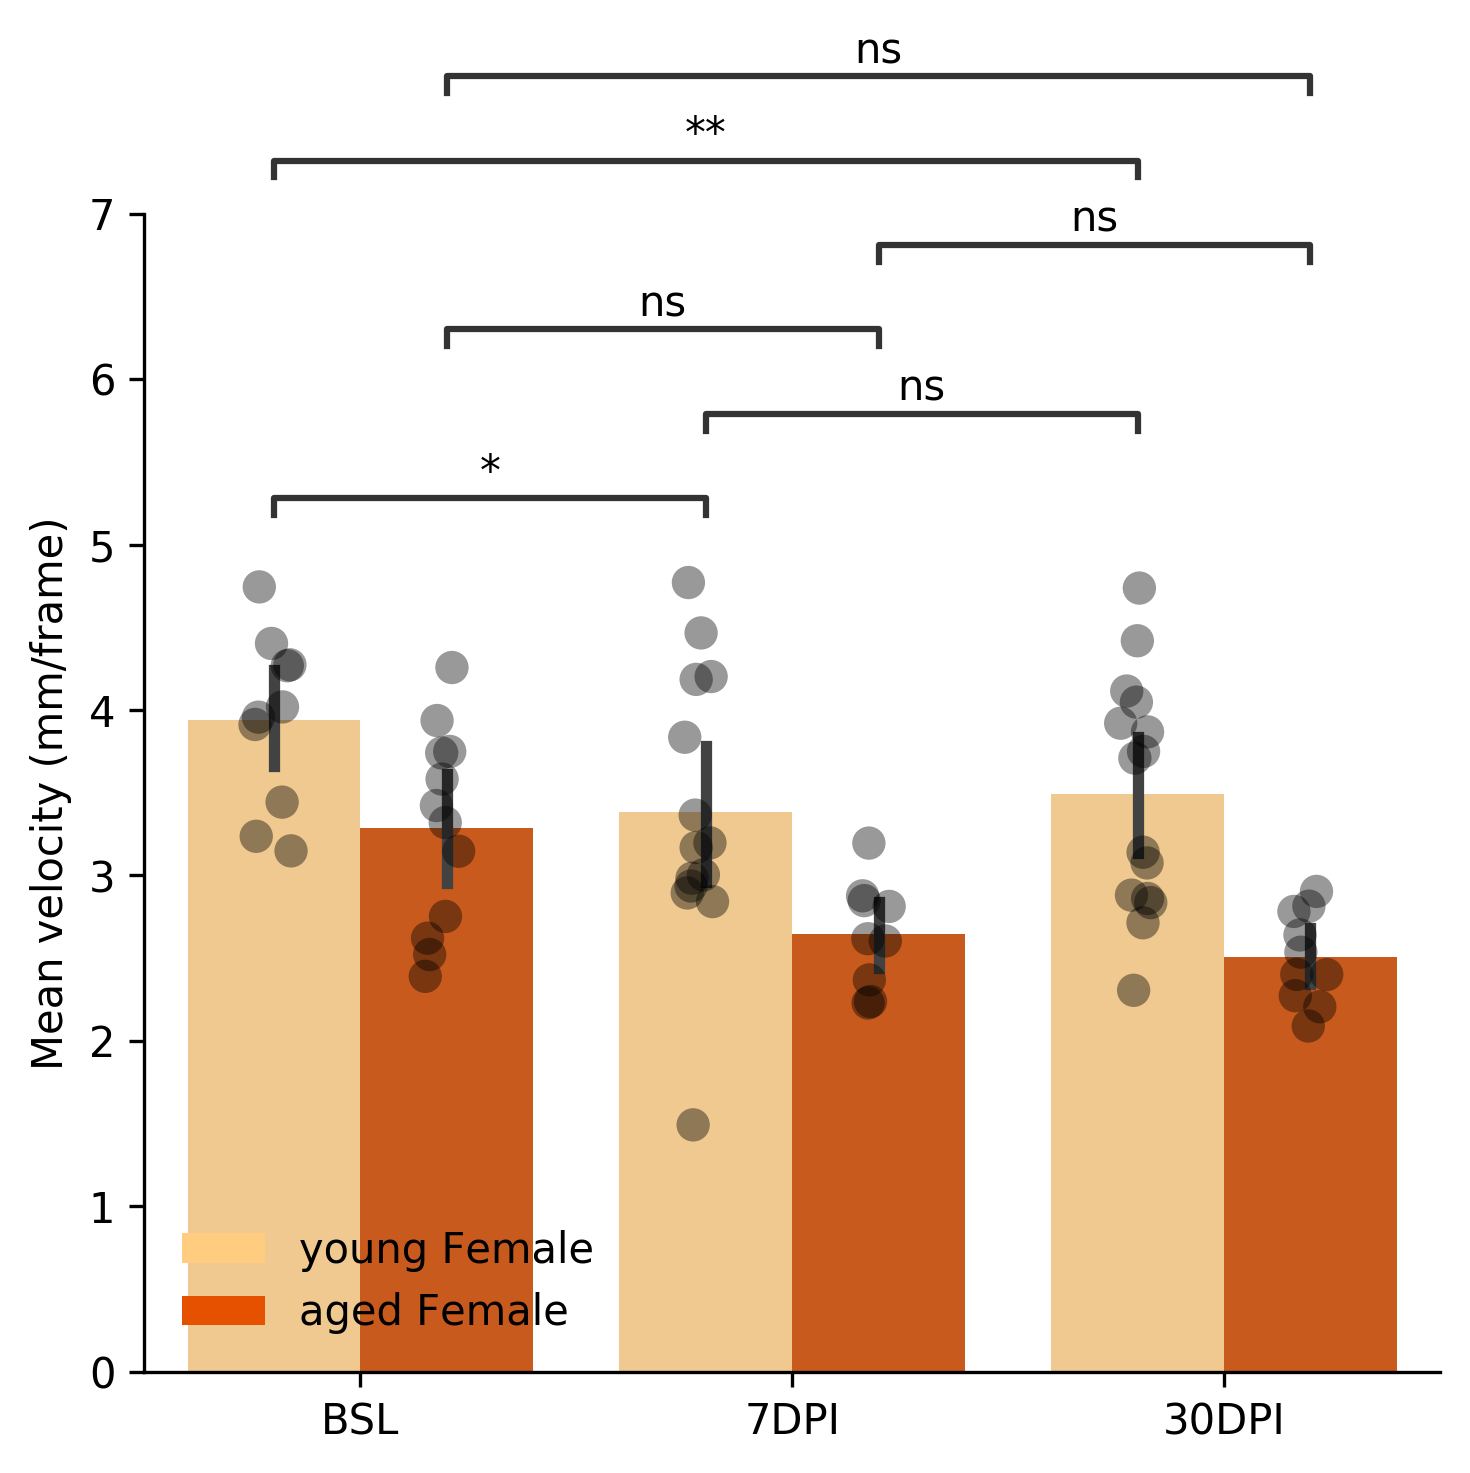

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BSL_aged Female vs. 7DPI_aged Female: Mann-Whitney-Wilcoxon test two-sided, P_val:3.019e-02 U_stat=8.500e+01
7DPI_aged Female vs. 30DPI_aged Female: Mann-Whitney-Wilcoxon test two-sided, P_val:4.379e-01 U_stat=5.500e+01
BSL_young Female vs. 7DPI_young Female: Mann-Whitney-Wilcoxon test two-sided, P_val:6.512e-02 U_stat=1.020e+02
7DPI_young Female vs. 30DPI_young Female: Mann-Whitney-Wilcoxon test two-sided, P_val:9.826e-01 U_stat=1.040e+02
BSL_aged Female vs. 30DPI_aged Female: Mann-Whitney-Wilcoxon test two-sided, P_val:5.073e-03 U_stat=1.030e+02
BSL_young Female vs. 30DPI_young Female: Mann-Whitney-Wilcoxon test two-sided, P_val:1.018e-01 U_stat=1.050e+02


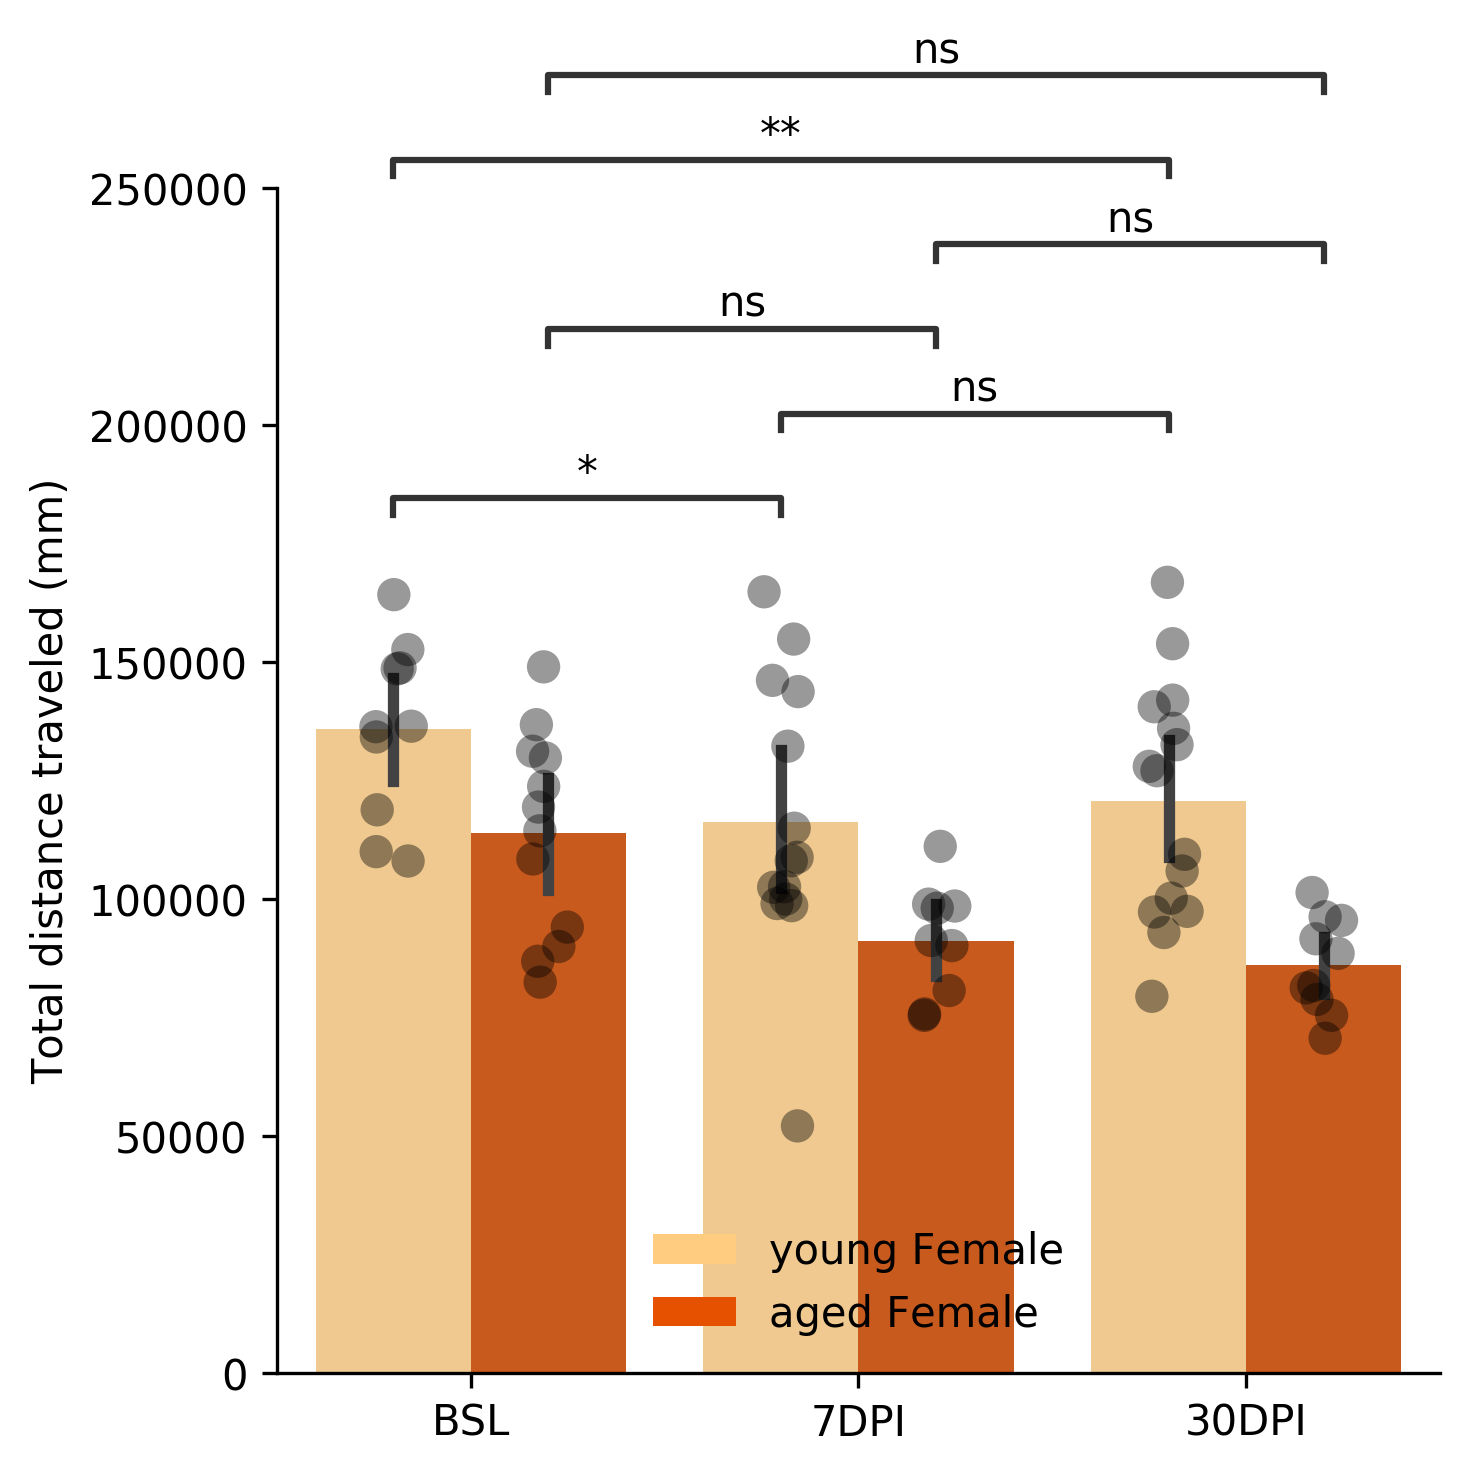

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BSL_aged Male vs. 7DPI_aged Male: Mann-Whitney-Wilcoxon test two-sided, P_val:1.566e-02 U_stat=1.920e+02
7DPI_aged Male vs. 30DPI_aged Male: Mann-Whitney-Wilcoxon test two-sided, P_val:5.523e-01 U_stat=1.530e+02
BSL_young Male vs. 7DPI_young Male: Mann-Whitney-Wilcoxon test two-sided, P_val:5.179e-03 U_stat=2.900e+02
7DPI_young Male vs. 30DPI_young Male: Mann-Whitney-Wilcoxon test two-sided, P_val:1.043e-07 U_stat=4.460e+02
BSL_aged Male vs. 30DPI_aged Male: Mann-Whitney-Wilcoxon test two-sided, P_val:2.188e-03 U_stat=1.980e+02
BSL_young Male vs. 30DPI_young Male: Mann-Whitney-Wilcoxon test two-sided, P_val:2.169e-08 U_stat=4.780e+02


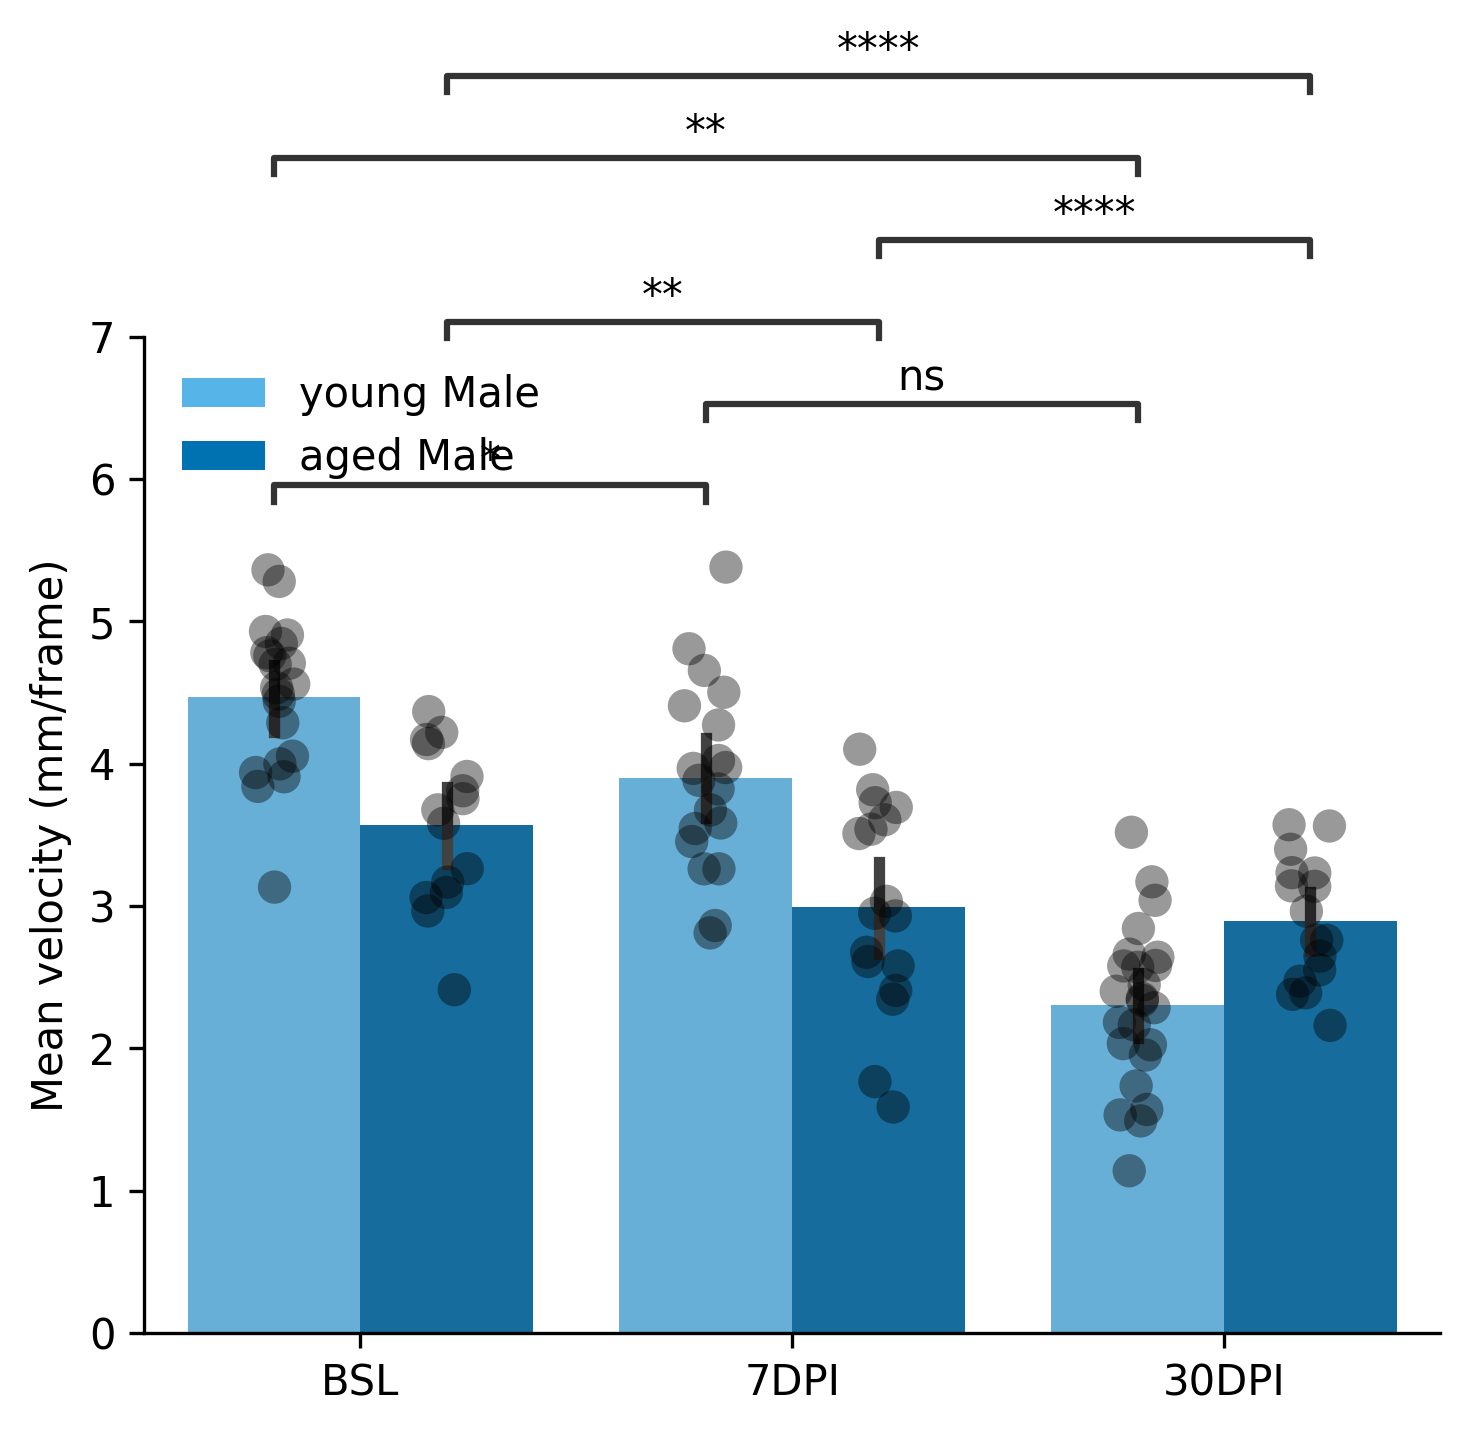

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BSL_aged Male vs. 7DPI_aged Male: Mann-Whitney-Wilcoxon test two-sided, P_val:1.410e-02 U_stat=1.930e+02
7DPI_aged Male vs. 30DPI_aged Male: Mann-Whitney-Wilcoxon test two-sided, P_val:5.052e-01 U_stat=1.550e+02
BSL_young Male vs. 7DPI_young Male: Mann-Whitney-Wilcoxon test two-sided, P_val:6.700e-03 U_stat=2.870e+02
7DPI_young Male vs. 30DPI_young Male: Mann-Whitney-Wilcoxon test two-sided, P_val:1.861e-07 U_stat=4.580e+02
BSL_aged Male vs. 30DPI_aged Male: Mann-Whitney-Wilcoxon test two-sided, P_val:1.675e-03 U_stat=2.000e+02
BSL_young Male vs. 30DPI_young Male: Mann-Whitney-Wilcoxon test two-sided, P_val:1.797e-08 U_stat=4.970e+02


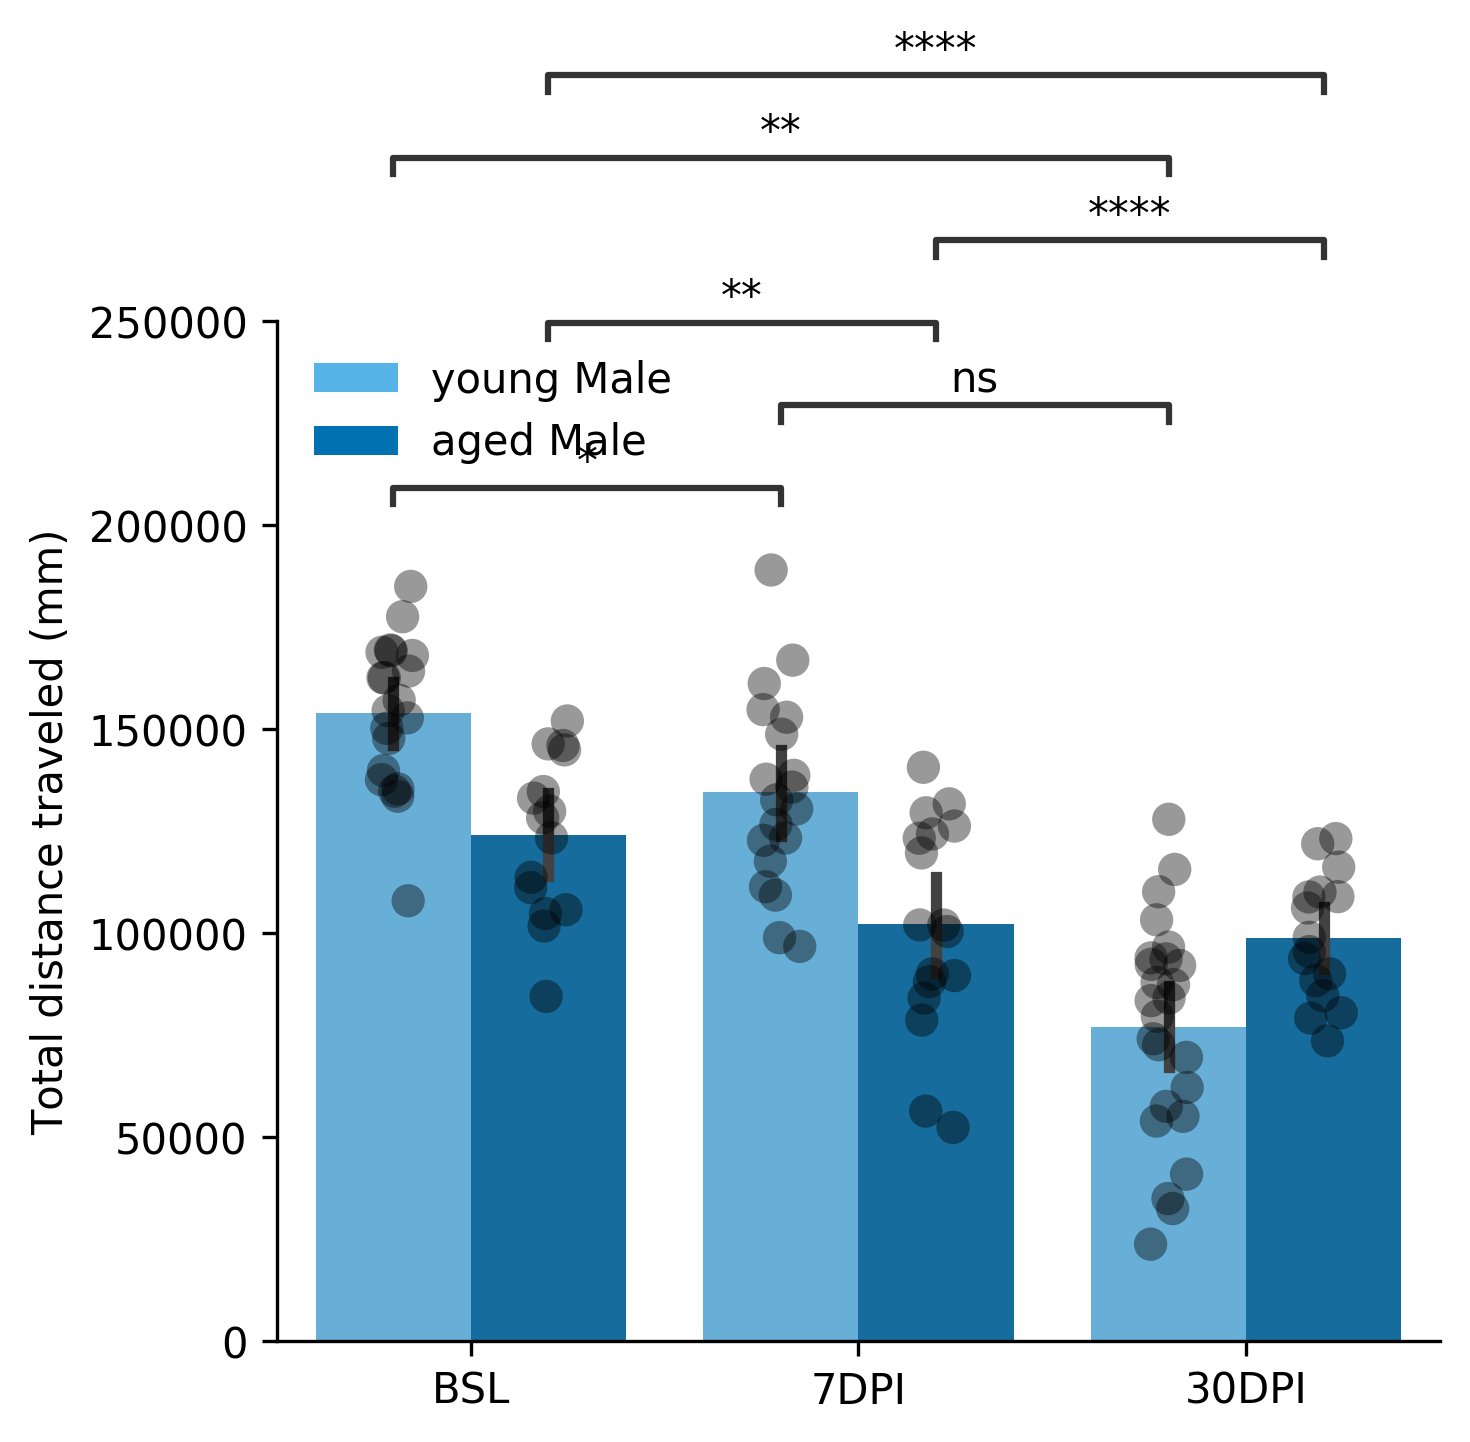

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BSL_aged Female vs. 7DPI_aged Female: Mann-Whitney-Wilcoxon test two-sided, P_val:3.902e-02 U_stat=8.100e+01
7DPI_aged Female vs. 30DPI_aged Female: Mann-Whitney-Wilcoxon test two-sided, P_val:9.229e-02 U_stat=3.200e+01
BSL_young Female vs. 7DPI_young Female: Mann-Whitney-Wilcoxon test two-sided, P_val:1.253e-03 U_stat=1.660e+02
7DPI_young Female vs. 30DPI_young Female: Mann-Whitney-Wilcoxon test two-sided, P_val:2.437e-03 U_stat=1.250e+02
BSL_aged Female vs. 30DPI_aged Female: Mann-Whitney-Wilcoxon test two-sided, P_val:3.845e-02 U_stat=5.400e+01
BSL_young Female vs. 30DPI_young Female: Mann-Whitney-Wilcoxon test two-sided, P_val:1.421e-05 U_stat=1.900e+02


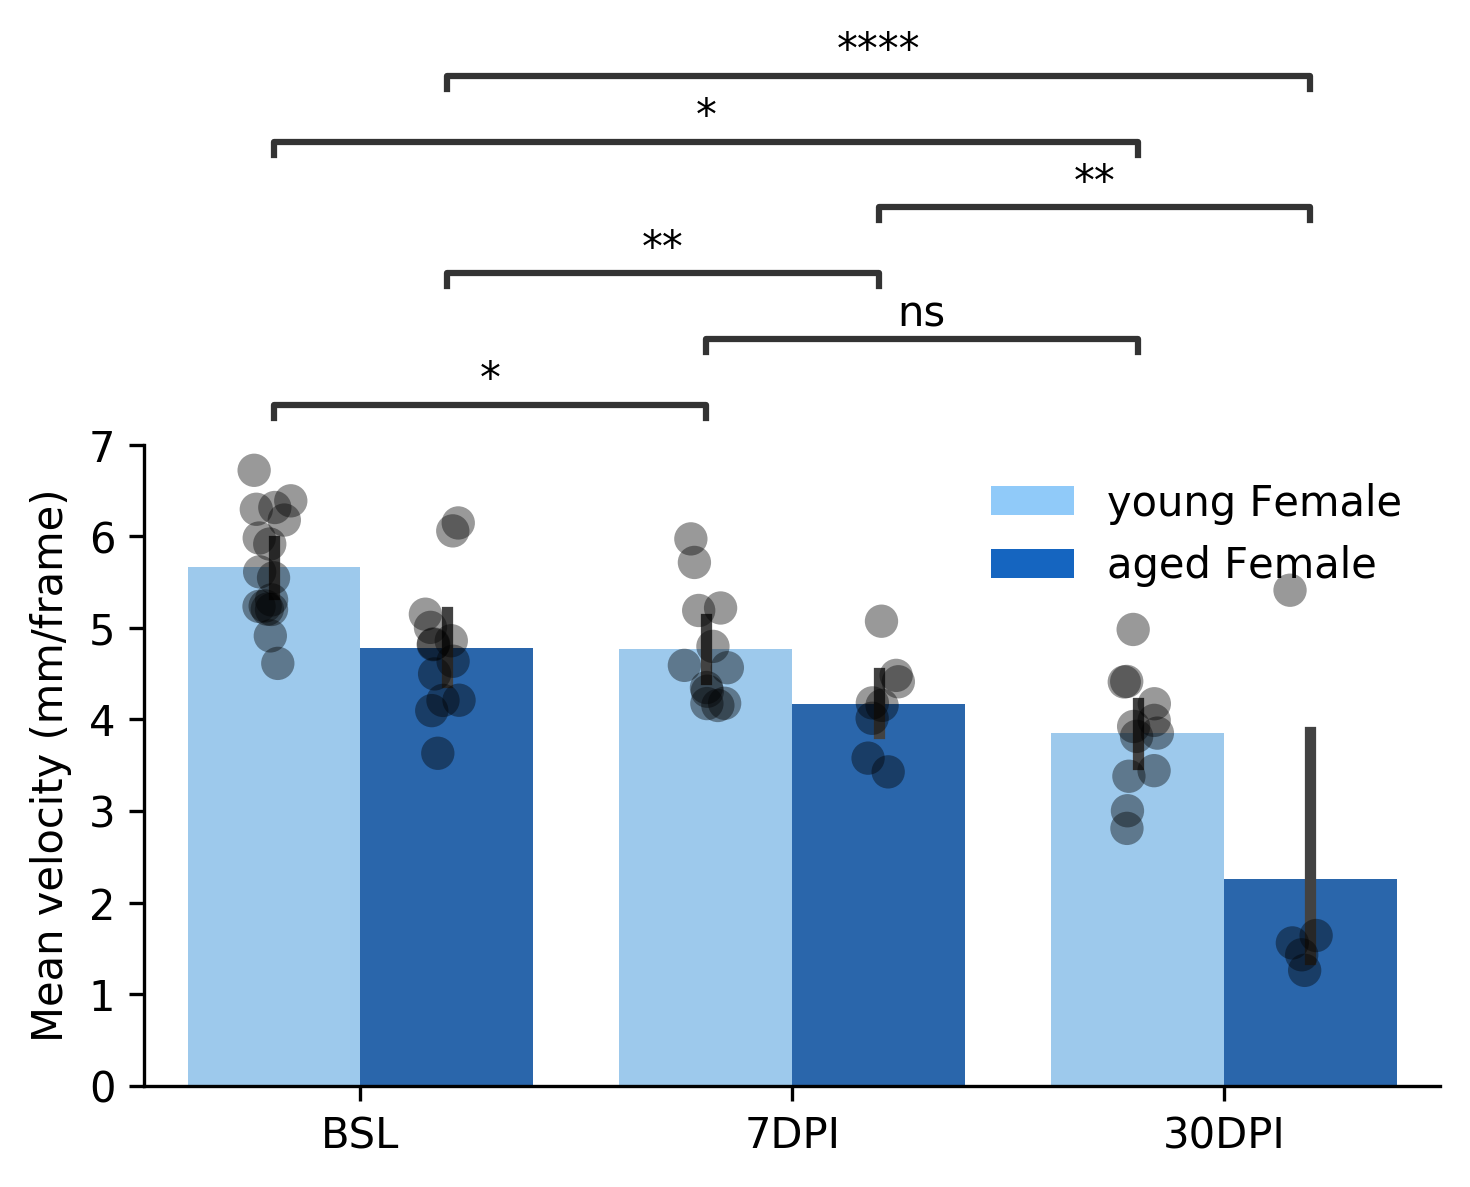

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BSL_aged Female vs. 7DPI_aged Female: Mann-Whitney-Wilcoxon test two-sided, P_val:3.902e-02 U_stat=8.100e+01
7DPI_aged Female vs. 30DPI_aged Female: Mann-Whitney-Wilcoxon test two-sided, P_val:9.229e-02 U_stat=3.200e+01
BSL_young Female vs. 7DPI_young Female: Mann-Whitney-Wilcoxon test two-sided, P_val:2.750e-03 U_stat=1.610e+02
7DPI_young Female vs. 30DPI_young Female: Mann-Whitney-Wilcoxon test two-sided, P_val:2.437e-03 U_stat=1.250e+02
BSL_aged Female vs. 30DPI_aged Female: Mann-Whitney-Wilcoxon test two-sided, P_val:3.845e-02 U_stat=5.400e+01
BSL_young Female vs. 30DPI_young Female: Mann-Whitney-Wilcoxon test two-sided, P_val:1.421e-05 U_stat=1.900e+02


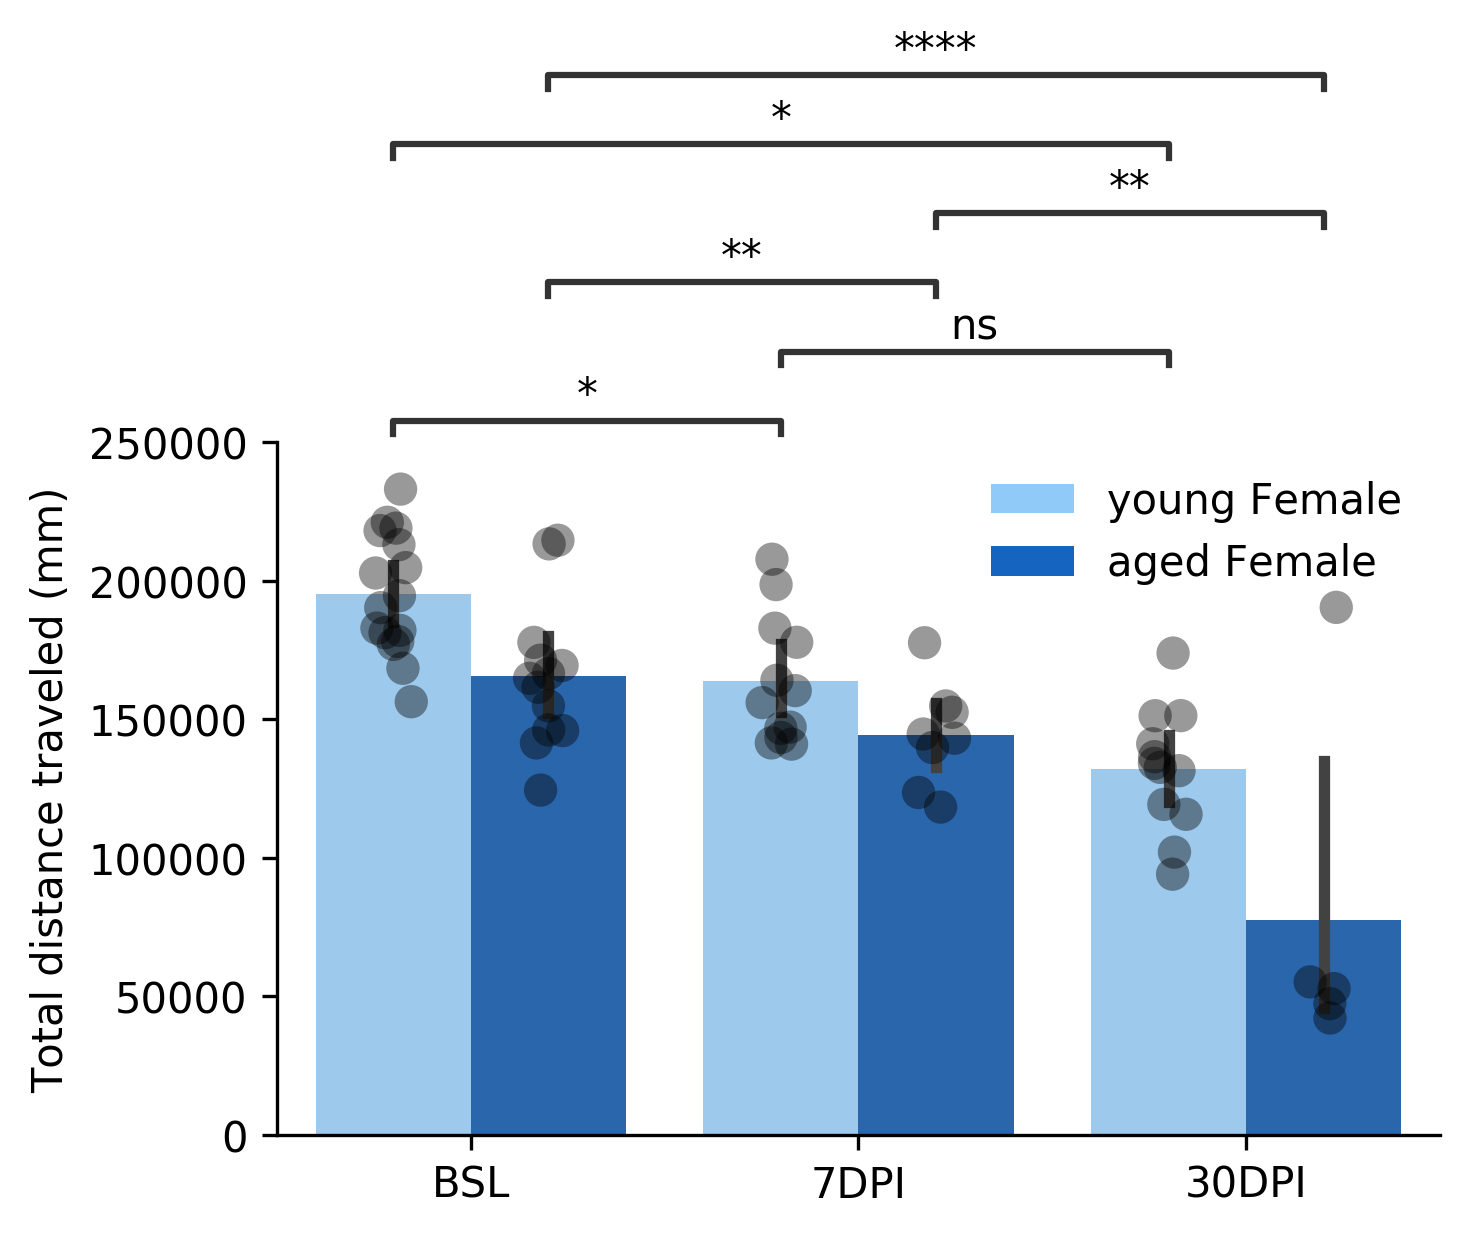

In [82]:
for stroke in ['CS', 'WMS']:
    for sex in ['Male', 'Female']:
        plot_metric(distance_df, stroke, sex,
                    metric='mean_velocity',
                    ylabel='Mean velocity (mm/frame)',
                    filename=f'velocity_{stroke}_{sex}.pdf')

        plot_metric(distance_df, stroke, sex,
                    metric='total_distance',
                    ylabel='Total distance traveled (mm)',
                    filename=f'distance_{stroke}_{sex}.pdf')